# Банковский консультант: RAG-система для автоматизации ответов клиентам

Итоговый проект реализует полный MVP RAG-системы для ответов на клиентские вопросы по банковским продуктам на основе синтетического набора документов.


## Цели проекта

- Подготовить базу знаний из банковских документов.
- Сравнить стратегии чанкинга и выбрать лучшую.
- Реализовать similarity, MMR, BM25 и hybrid retrieval.
- Собрать RAG-цепочку с LLM, историей диалога и цитированием источников.
- Оценить качество retrieval и generation, а также производительность.


In [ ]:
from pathlib import Path
import os
import re
import time
import json
import random
import warnings
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)


In [111]:
from pathlib import Path                           

# Загружаем документы из папки data
raw_documents = {}                                # Создаём словарь: ключ — имя файла, значение — текст документа
data_dir = Path("data")                           
for filepath in data_dir.iterdir():               
    if filepath.suffix == '.md':                  
        raw_documents[filepath.name] = filepath.read_text(encoding='utf-8')  
        

print('Загружено документов:', len(raw_documents))  

for name, text in raw_documents.items():            
    print(f'--- {name} ---')                        
    print(text[:400], '')                          

Загружено документов: 5
--- Кредит.md ---
## Потребительский кредит «Быстрый»

### Основные условия
- Сумма: от 50 000 до 5 000 000 рублей
- Ставка: от 12% до 19% годовых, зависит от скорингового балла
- Срок: от 12 до 84 месяцев
- Комиссия за выдачу: отсутствует
- Досрочное погашение: без штрафов, с первого дня

### Требования к заемщику
- Возраст: от 21 до 70 лет
- Стаж на текущем месте работы: от 3 месяцев
- Официальный доход, подтверж 
--- Депозит.md ---
## Депозит «Надежный»

### Основные условия
- Валюта: рубли
- Сумма: от 10 000 рублей
- Срок: от 3 до 36 месяцев
- Ставка: от 7% до 11% годовых в зависимости от срока и суммы
- Пополнение: возможно в течение первых 6 месяцев
- Частичное снятие: не предусмотрено

### Досрочное расторжение
При досрочном расторжении вклада проценты пересчитываются по ставке вклада «До востребования».

### Часто задав 
--- Ипотека.md ---
## Ипотека «Квартира мечты»

### Основные условия
- Цель: покупка квартиры на первичном или вторичном рынке
- Сумма 

In [112]:
from langchain_core.documents import Document


def detect_product_type(filename):
    s = filename.lower()                    # Приводим имя файла к нижнему регистру 
    if 'ипотек' in s:                       # Если в названии встречается подстрока про ипотеку, считаем продукт ипотечным
        return 'mortgage'
    if 'депозит' in s or 'вклад' in s:      # Если встречается депозит или вклад, относим документ к депозитам
        return 'deposit'
    if 'кредит' in s:                       # Если есть слово кредит, считаем продукт кредитным
        return 'credit'
    return 'general'                        # Во всех остальных случаях помечаем как общий продукт (general)



def normalize_text(text: str) -> str:
    text = text.replace('#', ' ')           # Заменяем символы заголовков Markdown (#) на пробелы, чтобы они не мешали анализу текста
    text = text.replace('\n', ' ')          # Заменяем переводы строк на пробелы, приводя текст к одной строке
    return text.strip()                     # Обрезаем пробелы по краям и возвращаем нормализованный текст



documents = []                               # Инициализируем список для объектов Document
for filename, text in raw_documents.items(): # Проходим по исходным документам: ключ — имя файла, значение — текст
    clean = normalize_text(text)            # Нормализуем текст: убираем решётки и переводы строк
    documents.append(Document(
        page_content=clean,                 # Сохраняем очищенный текст в поле page_content
        metadata={                          # Заполняем метаданные для последующей фильтрации и анализа
            'source': filename,             # Сохраняем исходное имя файла как источник
            'product_type': detect_product_type(filename),  # Определяем тип продукта по имени файла
            'doc_id': filename.replace('.md', ''),          # Формируем doc_id как имя файла без расширения .md
            'language': 'ru'                # Явно указываем язык документа как русский
        }
    ))


pd.DataFrame([
    {   # Формируем словарь с ключевыми характеристиками каждого документа
        'source': d.metadata['source'],                 # Имя исходного файла
        'product_type': d.metadata['product_type'],     # Определённый тип продукта
        'chars': len(d.page_content)                    # Длина очищенного текста в символах
    }
    for d in documents
])

,source,product_type,chars
0,Кредит.md,credit,749
1,Депозит.md,deposit,792
2,Ипотека.md,mortgage,856
3,FAQ.md,general,735
4,Кредиты.md,credit,512


## Этап 1. Подготовка данных и база знаний

Сравним три стратегии чанкинга: по размеру, по предложениям и рекурсивную. Для банковских документов важно не терять структуру условий, требований и FAQ.


In [113]:
import nltk
try:
    nltk.data.find('tokenizers/punkt')              
except LookupError:
    nltk.download('punkt')                         


from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter, NLTKTextSplitter


char_splitter = CharacterTextSplitter(              # Текстовый сплиттер, который режет текст по символам
    chunk_size=350,                                 # Максимальный размер чанка в символах
    chunk_overlap=60,                               # Целевой оверлап между соседними чанками (в символах)
    separator=''                                    # Разделитель — пустая строка, т.е. разбивка не привязана к пробелам/строкам
)
sent_splitter = NLTKTextSplitter(                   # Сплиттер, который использует NLTK для разбиения по предложениям
    chunk_size=350,                                
    chunk_overlap=60                                
)
rec_splitter = RecursiveCharacterTextSplitter(      # Рекурсивный сплиттер, который пытается сохранить структуру текста
    chunk_size=350,                                 
    chunk_overlap=60,                               
    separators=['', ',', '. ', '!', '?']              
)


chunk_variants = {
    'char': char_splitter.split_documents(documents),      
    'sentence': sent_splitter.split_documents(documents),   
    'recursive': rec_splitter.split_documents(documents)    
}


chunk_stats_df = pd.DataFrame([                    # Строим таблицу со статистикой по каждому варианту чанкинга
    {
        'strategy': name,                          
        'n_chunks': len(chunks),                   
        'avg_chunk_len': round(                    
            float(np.mean([len(c.page_content) for c in chunks])), 1
        ),
        'min_len': int(np.min([len(c.page_content) for c in chunks])),  
        'max_len': int(np.max([len(c.page_content) for c in chunks]))   
    }
    for name, chunks in chunk_variants.items()
])

chunk_stats_df                                      

Created a chunk of size 529, which is longer than the specified 350
Created a chunk of size 380, which is longer than the specified 350
Created a chunk of size 629, which is longer than the specified 350


,strategy,n_chunks,avg_chunk_len,min_len,max_len
0,char,14,298.6,155,350
1,sentence,11,334.0,104,629
2,recursive,14,298.6,155,350


In [114]:
for strategy, chunks in chunk_variants.items():
    print('=' * 80)
    print('Стратегия:', strategy)
    print('Число чанков:', len(chunks))
    print(chunks[0].page_content[:700])
    print()


Стратегия: char
Число чанков: 14
Потребительский кредит «Быстрый»      Основные условия - Сумма: от 50 000 до 5 000 000 рублей - Ставка: от 12% до 19% годовых, зависит от скорингового балла - Срок: от 12 до 84 месяцев - Комиссия за выдачу: отсутствует - Досрочное погашение: без штрафов, с первого дня      Требования к заемщику - Возраст: от 21 до 70 лет - Стаж на текущем месте раб

Стратегия: sentence
Число чанков: 11
Потребительский кредит «Быстрый»      Основные условия - Сумма: от 50 000 до 5 000 000 рублей - Ставка: от 12% до 19% годовых, зависит от скорингового балла - Срок: от 12 до 84 месяцев - Комиссия за выдачу: отсутствует - Досрочное погашение: без штрафов, с первого дня      Требования к заемщику - Возраст: от 21 до 70 лет - Стаж на текущем месте работы: от 3 месяцев - Официальный доход, подтвержденный справкой 2-НДФЛ или по форме банка - Гражданство: РФ      Часто задаваемые вопросы Вопрос: Можно ли погасить кредит досрочно?

Стратегия: recursive
Число чанков: 14
Потребите

### Выводы по чанкингу

Sentence‑вариант даёт более семантически целостные фрагменты (чанки строго по предложениям), но ценой того, что отдельные чанки могут быть заметно длиннее таргетного размера, что влияет на токенизацию и стоимость/контекст LLM. Recursive‑чанкинг даёт ту же стабильную статистику, что и посимвольный, но лучше сохраняет структуру.

In [115]:
final_chunks = chunk_variants['recursive']
for idx, chunk in enumerate(final_chunks):
    chunk.metadata['chunk_id'] = f'chunk_{idx:03d}'
    chunk.metadata['chunk_len'] = len(chunk.page_content)

pd.DataFrame([
    {
        'chunk_id': c.metadata['chunk_id'],
        'source': c.metadata['source'],
        'product_type': c.metadata['product_type'],
        'chunk_len': c.metadata['chunk_len'],
        'preview': c.page_content[:120]
    }
    for c in final_chunks
]).head(10)


,chunk_id,source,product_type,chunk_len,preview
0,chunk_000,Кредит.md,credit,350,Потребительский кредит «Быстрый» Основные...
1,chunk_001,Кредит.md,credit,349,мщику - Возраст: от 21 до 70 лет - Стаж на тек...
2,chunk_002,Кредит.md,credit,169,"дня, штрафы не взимаются. Вопрос: Можно ли по..."
3,chunk_003,Депозит.md,deposit,350,Депозит «Надежный» Основные условия - Вал...
4,chunk_004,Депозит.md,deposit,350,досрочном расторжении вклада проценты пересчит...
5,chunk_005,Депозит.md,deposit,212,ри досрочном закрытии? Ответ: Проценты пересчи...
6,chunk_006,Ипотека.md,mortgage,350,Ипотека «Квартира мечты» Основные условия...
7,chunk_007,Ипотека.md,mortgage,350,и жилья - Обязательное страхование: жизни и им...
8,chunk_008,Ипотека.md,mortgage,276,о ли оформить ипотеку без первоначального взно...
9,chunk_009,FAQ.md,general,350,Общий FAQ по продуктам банка Кредиты Вопр...


## Эмбеддинги и векторная база

Основная модель эмбеддингов — `intfloat/multilingual-e5-large`, так как она хорошо работает с русскоязычными запросами и документами. 

In [121]:
from langchain_community.embeddings import HuggingFaceEmbeddings

EMBED_MODEL_CANDIDATES = ['intfloat/multilingual-e5-large', 'intfloat/multilingual-e5-base']
embedding_model = None
embedding_model_name = None
for candidate in EMBED_MODEL_CANDIDATES:
    try:
        embedding_model = HuggingFaceEmbeddings(
            model_name=candidate,
            model_kwargs={'device': 'cpu'},
            encode_kwargs={'normalize_embeddings': True}
        )
        _ = embedding_model.embed_query('query: условия ипотечного кредита')
        embedding_model_name = candidate
        break
    except Exception as e:
        print(f'Не удалось загрузить {candidate}: {e}')

if embedding_model is None:
    raise RuntimeError('Не удалось загрузить embedding-модель')
print('Используемая модель:', embedding_model_name)


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 17674.79it/s]
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используемая модель: intfloat/multilingual-e5-large


In [ ]:
from langchain_community.vectorstores import Chroma  # Импортируем векторное хранилище Chroma из LangChain-компонентов
import shutil                                        # Модуль для работы с файлами и каталогами (удаление старой базы)


BASE_DIR = Path(os.getcwd())                         # Берём текущую рабочую директорию как базовую для проекта


persist_dir = BASE_DIR / 'chroma_db'                 # Путь к папке, где будет лежать база Chroma
if persist_dir.exists():                             # Если такая папка уже есть (старая версия базы)...
    shutil.rmtree(persist_dir)                       # ...полностью удаляем её, чтобы начать с чистого состояния.


vectorstore = Chroma.from_documents(                 # Создаём и сразу наполняем векторное хранилище Chroma
    documents=final_chunks,                          # Список чанков Document, которые нужно заэмбеддить и сохранить
    embedding=embedding_model,                       # Функция/объект эмбеддингов, которую Chroma будет вызывать внутри
    persist_directory=str(persist_dir),              # Директория для персистентного хранения базы на диске
    collection_name='bank_consultant_kb'             # Имя коллекции в Chroma (удобно для последующей загрузки)
)


embeddings_matrix = embedding_model.embed_documents( # Явно считаем эмбеддинги для всех чанков (для анализа/отчёта)
    [c.page_content for c in final_chunks]           # Передаём список текстов чанков в модель эмбеддингов
)           

In [126]:
print('Число чанков:', len(final_chunks))           
print('Размерность эмбеддингов:', len(embeddings_matrix[0]))  
print('База сохранена в:', persist_dir)   

Число чанков: 14
Размерность эмбеддингов: 1024
База сохранена в: /Users/kasyanenko/Desktop/MA/NLP2/tests-main/chroma_db


## Этап 2. Система ретрива

Реализуем similarity search, MMR, BM25. Также добавим фильтрацию по метаданным и контекстное сжатие.


In [127]:
similarity_retriever = vectorstore.as_retriever(          # Создаём ретривер поверх Chroma с обычным поиском по близости эмбеддингов
    search_type='similarity',                             # Режим: вернуть наиболее похожие документы по векторной близости
    search_kwargs={'k': 4}                                # Возвращаем top-4 наиболее релевантных чанка
)
mmr_retriever = vectorstore.as_retriever(                 # Создаём MMR-ретривер на той же векторной базе
    search_type='mmr',                                    # Режим MMR: баланс между релевантностью и разнообразием результатов
    search_kwargs={'k': 4, 'fetch_k': 8, 'lambda_mult': 0.5}  
    # Сначала берём 8 кандидатов, затем выбираем 4 финальных;
    # lambda_mult=0.5 означает компромисс между похожестью на запрос и непохожестью друг на друга.
)


from rank_bm25 import BM25Okapi                          # Импортируем класс BM25 для лексического поиска по словам


def tokenize_ru(text: str):
    return re.findall(r'\w+', text.lower())              # Простейшая токенизация: приводим к нижнему регистру и извлекаем слова/числа


bm25 = BM25Okapi([tokenize_ru(c.page_content) for c in final_chunks])  
# Строим BM25-индекс по всем чанкам: каждый чанк превращаем в список токенов


class BM25RetrieverSimple:
    def __init__(self, chunks, bm25_index):
        self.chunks = chunks                             # Сохраняем исходный список чанков
        self.bm25 = bm25_index                           # Сохраняем готовый BM25-индекс

    def get_relevant_documents(self, query, k=4, product_type=None):
        scores = self.bm25.get_scores(tokenize_ru(query))  # Считаем BM25-оценку релевантности каждого чанка запросу
        order = np.argsort(scores)[::-1]                 # Сортируем индексы чанков по убыванию score
        docs = []                                        # Список для итоговых релевантных документов
        for idx in order:                                # Идём по чанкам от наиболее релевантных к наименее релевантным
            doc = self.chunks[int(idx)]                  # Берём очередной чанк по индексу

            if product_type and doc.metadata.get('product_type') != product_type:
                continue                                 # Если задан фильтр по продукту, пропускаем чанки других типов

            docs.append(Document(
                page_content=doc.page_content,           # Кладём в выдачу текст найденного чанка
                metadata={**doc.metadata, 'bm25_score': float(scores[idx])}
                # Копируем все исходные метаданные и добавляем BM25-score для отладки и анализа
            ))

            if len(docs) >= k:                           # Как только набрали k документов...
                break                                    # ...останавливаем поиск.

        return docs                                      # Возвращаем top-k релевантных чанков


bm25_retriever = BM25RetrieverSimple(final_chunks, bm25)  
# Создаём готовый BM25-ретривер поверх набора финальных чанков

In [128]:
from langchain_core.documents import Document   # Класс документа LangChain с текстом и метаданными


def vector_search(query: str, k: int = 4, product_type: Optional[str] = None):
    docs_scores = vectorstore.similarity_search_with_relevance_scores(
        query,
        k=min(max(k * 2, 4), len(final_chunks))  # Берём расширенный пул кандидатов для последующей фильтрации по типу продукта
    )
    results = []                                 # Список для итоговых документов после фильтрации

    for doc, score in docs_scores:              # Проходим по документам и их нормализованным релевантностям 0–1
        if product_type and doc.metadata.get('product_type') != product_type:
            continue                            # Пропускаем документы, не соответствующие заданному типу продукта
        doc.metadata['vector_score'] = float(score)  # Сохраняем численную оценку релевантности в метаданные для анализа
        results.append(doc)                     # Добавляем документ в итоговый список
        if len(results) >= k:
            break                               # Останавливаемся, когда набрали нужное количество документов

    return results                              # Возвращаем top‑k документов после фильтрации и аннотации score



def compress_document(doc: Document, query: str, max_sentences: int = 3) -> Document:
    sentences = re.split(r'(?<=[.!?])\s+|\n+', doc.page_content)  # Разбиваем текст на предложения и строки по знакам конца предложения
    sentences = [s.strip() for s in sentences if s.strip()]       # Убираем пустые элементы и пробелы по краям
    q_tokens = set(tokenize_ru(query))                            # Токены запроса как множество для быстрого пересечения
    scored = []                                                   # Список пар (score, предложение)

    for sent in sentences:                                        # Проходим по всем предложениям документа
        s = sent.strip()                                          # Нормализуем пробелы в предложении
        if not s:
            continue                                              # Пропускаем пустые строки на всякий случай
        score = len(q_tokens & set(tokenize_ru(s)))               # Оцениваем предложение по количеству общих токенов с запросом 
        scored.append((score, s))                                 # Сохраняем score и текст предложения

    top = [s for _, s in sorted(scored, key=lambda x: x[0], reverse=True)[:max_sentences]]
    # Берём несколько предложений с наибольшим пересечением по токенам с запросом

    compressed = ' '.join(top) if top else doc.page_content[:300] # Если нашлись релевантные предложения, собираем их, иначе берём начало текста
    return Document(
        page_content=compressed,                                  # Краткий текст документа, ориентированный на запрос
        metadata={**doc.metadata, 'compressed': True}             # Копируем исходные метаданные и помечаем документ как сжатый
    )



def hybrid_search(query: str, k: int = 4, alpha: float = 0.6, product_type: Optional[str] = None, compress: bool = False):
    vec_docs = vector_search(query, k=max(6, k), product_type=product_type)
    # Получаем расширенный список кандидатов из векторного поиска

    bm_docs = bm25_retriever.get_relevant_documents(query, k=max(6, k), product_type=product_type)
    # Получаем расширенный список кандидатов из BM25‑поиска


    merged = {}                                                   # Словарь кандидатов, объединённых по chunk_id
    for rank, doc in enumerate(vec_docs, start=1):                # Обходим векторный список с ранжированием
        cid = doc.metadata['chunk_id']                            # Берём идентификатор чанка
        merged.setdefault(cid, {'doc': doc, 'vec_rank': 999, 'bm_rank': 999})
        # Если чанк ещё не встречался, создаём запись с большими рангами по умолчанию
        merged[cid]['vec_rank'] = rank                            # Запоминаем место документа в векторном ранжировании

    for rank, doc in enumerate(bm_docs, start=1):                 # Аналогично обрабатываем BM25‑выдачу
        cid = doc.metadata['chunk_id']
        merged.setdefault(cid, {'doc': doc, 'vec_rank': 999, 'bm_rank': 999})
        merged[cid]['bm_rank'] = rank                             # Сохраняем ранг документа в списке BM25


    rescored = []                                                 # Список документов с пересчитанным гибридным score
    for cid, item in merged.items():                              # Обходим все объединённые кандидаты
        score = alpha * (1 / item['vec_rank']) + (1 - alpha) * (1 / item['bm_rank'])
        # Гибридный score как взвешенная сумма обратных рангов из двух списков в духе rank‑fusion 
        item['doc'].metadata['hybrid_score'] = float(score)       # Сохраняем гибридный score в метаданные документа
        rescored.append((score, item['doc']))                     # Добавляем пару (score, документ) в список

    rescored = sorted(rescored, key=lambda x: x[0], reverse=True)[:k]
    # Сортируем документы по убыванию гибридного score и берём top‑k

    docs = [
        compress_document(doc, query) if compress else doc        # При необходимости сжимаем документы до релевантных предложений
        for score, doc in rescored
    ]
    return docs                                                   # Возвращаем список гибридно отранжированных документов



def pretty_results(docs):
    return pd.DataFrame([                                         # Преобразуем список документов в компактную таблицу для просмотра
        {
            'chunk_id': d.metadata.get('chunk_id'),               # Идентификатор чанка
            'source': d.metadata.get('source'),                   # Имя исходного файла
            'product_type': d.metadata.get('product_type'),       # Тип продукта из метаданных
            'preview': d.page_content[:140]                       # Первые 140 символов текста для быстрого просмотра
        }
        for d in docs
    ])


query_demo = 'можно ли досрочно погасить потребительский кредит без штрафа'  
print('SIMILARITY')
display(pretty_results(similarity_retriever.invoke(query_demo)))  
print('MMR')
display(pretty_results(mmr_retriever.invoke(query_demo)))         
print('BM25')
display(pretty_results(bm25_retriever.get_relevant_documents(query_demo)))  
print('HYBRID + compression')
display(pretty_results(hybrid_search(query_demo, compress=True))) 

SIMILARITY


,chunk_id,source,product_type,preview
0,chunk_001,Кредит.md,credit,мщику - Возраст: от 21 до 70 лет - Стаж на тек...
1,chunk_000,Кредит.md,credit,Потребительский кредит «Быстрый» Основные...
2,chunk_002,Кредит.md,credit,"дня, штрафы не взимаются. Вопрос: Можно ли по..."
3,chunk_007,Ипотека.md,mortgage,и жилья - Обязательное страхование: жизни и им...


MMR


,chunk_id,source,product_type,preview
0,chunk_001,Кредит.md,credit,мщику - Возраст: от 21 до 70 лет - Стаж на тек...
1,chunk_000,Кредит.md,credit,Потребительский кредит «Быстрый» Основные...
2,chunk_004,Депозит.md,deposit,досрочном расторжении вклада проценты пересчит...
3,chunk_009,FAQ.md,general,Общий FAQ по продуктам банка Кредиты Вопр...


BM25


,chunk_id,source,product_type,preview
0,chunk_001,Кредит.md,credit,мщику - Возраст: от 21 до 70 лет - Стаж на тек...
1,chunk_000,Кредит.md,credit,Потребительский кредит «Быстрый» Основные...
2,chunk_002,Кредит.md,credit,"дня, штрафы не взимаются. Вопрос: Можно ли по..."
3,chunk_008,Ипотека.md,mortgage,о ли оформить ипотеку без первоначального взно...


HYBRID + compression


,chunk_id,source,product_type,preview
0,chunk_001,Кредит.md,credit,мщику - Возраст: от 21 до 70 лет - Стаж на тек...
1,chunk_000,Кредит.md,credit,Потребительский кредит «Быстрый» Основные...
2,chunk_002,Кредит.md,credit,Вопрос: Можно ли получить кредит без справки о...
3,chunk_007,Ипотека.md,mortgage,и жилья - Обязательное страхование: жизни и им...


По этим таблицам видно, что все четыре стратегии вытаскивают очень согласованный набор чанков: везде доминируют фрагменты из Кредит.md, а также иногда подключаются релевантные куски из Ипотека.md и FAQ.md. Это логично для запроса про досрочное погашение потребительского кредита без штрафа, и особенно хорошо видно, что гибрид + compression даёт те же по сути документы, но с уже укороченным, более «плотным» контекстом для LLM, что снижает риск размытых ответов.

## Тестовый набор и retrieval-оценка

Создаём 20 вопросов клиентов и задаём эталонные чанки. Затем считаем HitRate@4 и MRR для разных ретриверов.


In [129]:
def find_gold(*keywords, source=None):
    keywords = [k.lower() for k in keywords]
    matches = []
    for c in final_chunks:
        text = c.page_content.lower()
        if source and c.metadata['source'] != source:
            continue
        if all(k in text for k in keywords):
            matches.append(c.metadata['chunk_id'])
    return matches

eval_questions = [
    {'question': 'Можно ли пополнять вклад Надежный?', 'gold_chunks': find_gold(source='Депозит.md')},
    {'question': 'Что будет с процентами при досрочном закрытии вклада?', 'gold_chunks': find_gold(source='Депозит.md')},
    {'question': 'Какая минимальная сумма вклада?', 'gold_chunks': find_gold(source='Депозит.md')},
    {'question': 'Какой срок у вклада Надежный?', 'gold_chunks': find_gold(source='Депозит.md')},
    {'question': 'Можно ли досрочно погасить потребительский кредит без штрафов?', 'gold_chunks': find_gold(source='Кредит.md')},
    {'question': 'Какой диапазон ставок по потребительскому кредиту Быстрый?', 'gold_chunks': find_gold(source='Кредит.md')},
    {'question': 'Какой возраст заёмщика нужен для потребительского кредита?', 'gold_chunks': find_gold(source='Кредит.md')},
    {'question': 'Можно ли получить кредит без справки о доходах?', 'gold_chunks': find_gold(source='Кредит.md')},
    {'question': 'Как подать заявку на кредит?', 'gold_chunks': find_gold(source='FAQ.md')},
    {'question': 'Сколько рассматривается заявка по ипотеке?', 'gold_chunks': find_gold(source='FAQ.md')},
    {'question': 'Какой максимальный размер страхования вкладов?', 'gold_chunks': find_gold(source='FAQ.md')},
    {'question': 'Есть ли кэшбэк по дебетовой карте?', 'gold_chunks': find_gold(source='FAQ.md')},
    {'question': 'Какой минимальный первоначальный взнос по ипотеке?', 'gold_chunks': find_gold(source='Ипотека.md')},
    {'question': 'Можно ли использовать материнский капитал?', 'gold_chunks': find_gold(source='Ипотека.md')},
    {'question': 'Какой срок ипотечного кредита?', 'gold_chunks': find_gold(source='Ипотека.md')},
    {'question': 'Какие ставки по ипотеке для зарплатных и обычных клиентов?', 'gold_chunks': find_gold(source='Ипотека.md')},
    {'question': 'Какие требования к ипотечному заемщику по стажу?', 'gold_chunks': find_gold(source='Ипотека.md')},
    {'question': 'Какой возраст для ипотечного кредита?', 'gold_chunks': find_gold('21 до 65', source='Кредиты.md') + find_gold(source='Ипотека.md')},
    {'question': 'Какие требования к заемщику по автокредиту?', 'gold_chunks': find_gold(source='Кредиты.md')},
    {'question': 'Нужно ли КАСКО для автокредита?', 'gold_chunks': find_gold(source='Кредиты.md')},
]
for row in eval_questions:
    row['gold_chunks'] = sorted(set(row['gold_chunks']))
pd.DataFrame(eval_questions)


,question,gold_chunks
0,Можно ли пополнять вклад Надежный?,"[chunk_003, chunk_004, chunk_005]"
1,Что будет с процентами при досрочном закрытии ...,"[chunk_003, chunk_004, chunk_005]"
2,Какая минимальная сумма вклада?,"[chunk_003, chunk_004, chunk_005]"
3,Какой срок у вклада Надежный?,"[chunk_003, chunk_004, chunk_005]"
4,Можно ли досрочно погасить потребительский кре...,"[chunk_000, chunk_001, chunk_002]"
5,Какой диапазон ставок по потребительскому кред...,"[chunk_000, chunk_001, chunk_002]"
6,Какой возраст заёмщика нужен для потребительск...,"[chunk_000, chunk_001, chunk_002]"
7,Можно ли получить кредит без справки о доходах?,"[chunk_000, chunk_001, chunk_002]"
8,Как подать заявку на кредит?,"[chunk_009, chunk_010, chunk_011]"
9,Сколько рассматривается заявка по ипотеке?,"[chunk_009, chunk_010, chunk_011]"


In [130]:
def retrieve_ids(method: str, query: str, k: int = 4):
    if method == 'similarity':
        docs = similarity_retriever.invoke(query)                # Векторный ретривер по косинусной близости
    elif method == 'mmr':
        docs = mmr_retriever.invoke(query)                        # Векторный ретривер с MMR для диверсификации выдачи
    elif method == 'bm25':
        docs = bm25_retriever.get_relevant_documents(query, k=k)  # Лексический BM25‑ретривер
    elif method == 'hybrid':
        docs = hybrid_search(query, k=k, compress=False)          # Гибридный ретривер без сжатия текста
    elif method == 'hybrid_compressed':
        docs = hybrid_search(query, k=k, compress=True)           # Гибридный ретривер с компрессией чанков под запрос
    else:
        raise ValueError(method)                                  # Защита от опечаток в названии метода
    return [d.metadata['chunk_id'] for d in docs]                 # Возвращаем только идентификаторы чанков для метрик



def hit_rate_at_k(pred_ids, gold_ids, k=4):
    return int(any(pid in gold_ids for pid in pred_ids[:k]))      # HitRate@k: 1 если среди top‑k есть хотя бы один золотой чанк



def reciprocal_rank(pred_ids, gold_ids):
    for rank, pid in enumerate(pred_ids, start=1):                # Проходим по предсказанным чанкам в порядке ранга
        if pid in gold_ids:
            return 1.0 / rank                                     # Возвращаем обратный ранг первого совпадения (RR)
    return 0.0                                                     # Если ни один золотой чанк не найден, RR = 0


methods = ['similarity', 'mmr', 'bm25', 'hybrid', 'hybrid_compressed']  # Список стратегий, которые будем сравнивать
rows = []                                                           # Список для агрегированных метрик по методам
detailed_rows = []                                                  # Список для построчной детальной оценки по вопросам

for method in methods:                                              # Обходим все стратегии ретривала
    hits, rrs = [], []                                              # Списки значений HitRate@4 и RR по всем вопросам
    for sample in eval_questions:                                   # Идём по всем оценочным вопросам
        pred = retrieve_ids(method, sample['question'], k=4)        # Получаем список предсказанных chunk_id
        hr = hit_rate_at_k(pred, sample['gold_chunks'], k=4)        # Считаем HitRate@4 для данного вопроса
        rr = reciprocal_rank(pred, sample['gold_chunks'])           # Считаем Reciprocal Rank для данного вопроса
        hits.append(hr)                                            # Сохраняем hit в список
        rrs.append(rr)                                             # Сохраняем RR в список
        detailed_rows.append({                                     # Добавляем детальную строку для анализа
            'method': method,                                      # Название стратегии ретривера
            'question': sample['question'],                        # Текст вопроса
            'gold_chunks': ', '.join(sample['gold_chunks']),       # Список золотых чанков в виде строки
            'predicted': ', '.join(pred),                          # Предсказанные chunk_id
            'hit@4': hr,                                           # Hit@4 для данного вопроса
            'rr': rr                                               # Reciprocal Rank для данного вопроса
        })


    rows.append({
        'method': method,
        'HitRate@4': round(float(np.mean(hits)), 3),               # Средний HitRate@4 по всем вопросам для метода
        'MRR': round(float(np.mean(rrs)), 3)                       # Средний MRR (Mean Reciprocal Rank) для метода
    })


retrieval_metrics_df = pd.DataFrame(rows).sort_values(['HitRate@4', 'MRR'], ascending=False)

retrieval_metrics_df                                               

,method,HitRate@4,MRR
0,similarity,1.00,0.950
1,mmr,1.00,0.950
3,hybrid,1.00,0.942
4,hybrid_compressed,1.00,0.942
2,bm25,0.95,0.858


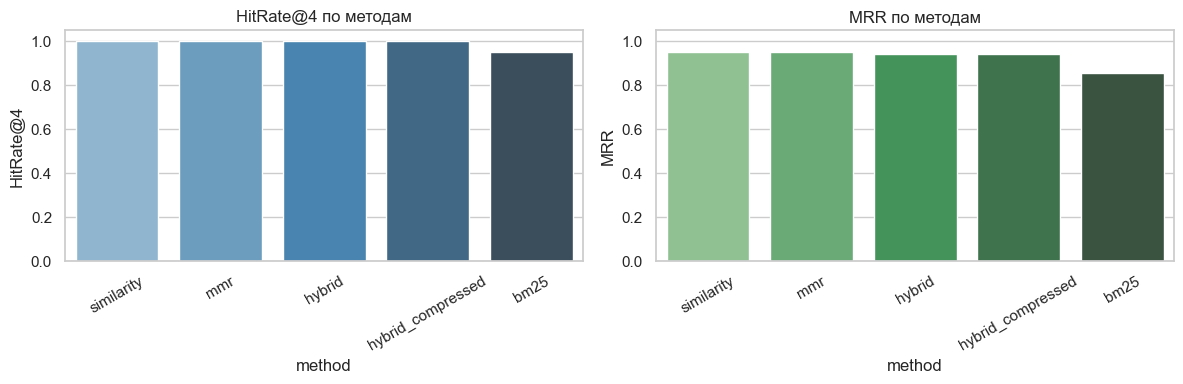

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=retrieval_metrics_df, x='method', y='HitRate@4', ax=axes[0], palette='Blues_d')
axes[0].set_title('HitRate@4 по методам')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=30)
sns.barplot(data=retrieval_metrics_df, x='method', y='MRR', ax=axes[1], palette='Greens_d')
axes[1].set_title('MRR по методам')
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'retrieval_metrics.png', dpi=180, bbox_inches='tight')
plt.show()


По метрикам видно, что для тестового набора вопросов все стратегии, кроме BM25, дают идеальный HitRate@4 = 1.0, то есть хотя бы один правильный чанк всегда попадает в top‑4 выдачи. При этом по MRR чуть лучше всего ведут себя чисто векторные методы `similarity` и `mmr` (0.95), гибрид и гибрид с компрессией почти не отстают (0.942), а BM25 заметно ниже и по HitRate (0.95) и по MRR (0.858). 

## Этап 3. Интеграция с LLM

Собираем RAG-цепочку, добавляем историю диалога, обработку отсутствия ответа и цитирование источников.


In [132]:
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM
import torch

In [133]:
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"


tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)               # Загружаем токенизатор для  модели Qwen2.5‑1.5B

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="auto",                                             # Автоматически распределяем веса по доступным устройствам (GPU/CPU) 
    torch_dtype=torch.float16                                      # Используем fp16 для экономии памяти и ускорения инференса на поддерживаемых GPU 
)


# Настраиваем параметры генерации
llm_pipeline = pipeline(
    "text-generation",                                             # Задаём задачу как генерацию текста
    model=model,                                                   
    tokenizer=tokenizer,                                           
    max_new_tokens=512,                                            # Ограничиваем максимальное число новых токенов в ответе
    temperature=0.01                                               # Очень низкая температура для максимально детерминированных и фактических ответов
)

Loading weights: 100%|██████████| 338/338 [00:03<00:00, 100.41it/s]


In [134]:
SYSTEM_PROMPT = '''
Ты - банковский консультант. Отвечай только на основе предоставленного контекста.
Если в контексте нет точного ответа, честно скажи, что информация не найдена в документации.
Отвечай по-русски, кратко и структурированно.
Обязательно указывай источники в формате [source:chunk_id].
Не придумывай условия, ставки, сроки или комиссии.
'''.strip()


In [135]:
PRODUCT_HINTS = {
    'ипотек': 'mortgage',      # Несколько интеллектуальных подсказок
    'вклад': 'deposit',        
    'депозит': 'deposit',     
    'кредит': 'credit',        
    'автокредит': 'credit'     
}


def infer_product_type(query: str) -> Optional[str]:
    q = query.lower()          # Нормализуем запрос к нижнему регистру
    for key, value in PRODUCT_HINTS.items():
        if key in q:           # Если какая‑то из подсказок по продукту встречается в запросе
            return value       # Возвращаем соответствующий тип продукта
    return None                # Если по запросу нельзя однозначно понять продукт, возвращаем None



def generate_multi_queries(query: str) -> List[str]:
    variants = [query]         # Всегда включаем исходный запрос в список вариантов
    q = query.lower()          # Работаем с нижним регистром для простых замен
    replacements = {
        'досрочно': 'досрочное погашение',    
        'вклад': 'депозит',                   
        'ипотека': 'ипотечный кредит',        
        'ставка': 'процентная ставка',        
        'первоначальный взнос': 'минимальный взнос'  
    }
    for old, new in replacements.items():
        if old in q:           # Если какое‑то ключевое слово есть в запросе
            variants.append(q.replace(old, new))  # Добавляем вариант с подстановкой альтернативной формулировки
    variants.append('условия ' + q)               # Добавляем ещё один вариант в виде "условия <запрос>"
    return list(dict.fromkeys(variants))[:4]      # Убираем дубликаты, ограничиваемся первыми четырьмя вариантами 



def rerank_by_overlap(query: str, docs: List[Document]) -> List[Document]:
    q_tokens = set(tokenize_ru(query))            # Множество токенов исходного запроса
    rescored = []                                 # Список документов с пересчитанным score
    for d in docs:
        overlap = len(q_tokens & set(tokenize_ru(d.page_content)))  # Число общих токенов запроса и текста документа
        score = d.metadata.get('hybrid_score', 0) + overlap * 0.05  # Добавляем к гибридному score небольшой бонус за токенное совпадение
        d.metadata['rerank_score'] = float(score)                   # Сохраняем новый rerank_score в метаданные
        rescored.append((score, d))               # Кладём пару (score, документ) для сортировки
    return [d for _, d in sorted(rescored, key=lambda x: x[0], reverse=True)]
    # Возвращаем документы в порядке убывания пересчитанного score, усиливая влияние точных совпадений 



def advanced_retrieve(query: str, k: int = 4) -> List[Document]:
    product_type = infer_product_type(query)      # Пытаемся вывести тип продукта из текста запроса
    all_docs = []                                 # Список всех кандидатов из разных переформулировок
    seen = set()                                  # Множество уже добавленных chunk_id, чтобы не было дублей
    for qv in generate_multi_queries(query):      # Обходим все сгенерированные варианты запроса
        docs = hybrid_search(qv, k=k, product_type=product_type, compress=True)
        # Делаем гибридный поиск с учётом типа продукта и компрессией контекста
        for d in docs:
            cid = d.metadata['chunk_id']          # Берём идентификатор чанка
            if cid not in seen:                   # Если этот чанк ещё не попадался
                seen.add(cid)                     # Помечаем его как использованный
                all_docs.append(d)                # Добавляем документ в общий пул кандидатов
    return rerank_by_overlap(query, all_docs)[:k] # Переранжируем кандидатов по пересечению токенов и берём top‑k 

In [136]:
def build_context(docs: List[Document]) -> str:
    return "\n\n".join(                                             # Склеиваем все чанки в один контекст через пустую строку
        f"[{d.metadata['source']}:{d.metadata['chunk_id']}] {d.page_content}"  # Перед каждым чанком ставим маркер с файлом и chunk_id для цитирования
        for d in docs
    )


def fallback_answer(query: str, docs: List[Document]) -> str:
    if not docs:
        return "В предоставленной документации не нашлось релевантной информации для ответа на ваш вопрос"
    bullets = []                                                    # Список маркеров с краткими выдержками из контекста
    for d in docs[:3]:                                              # Берём не более трёх чанков для fallback‑ответа
        snippet = d.page_content[:220].replace("\n", " ")           # Обрезаем текст до 220 символов и убираем переносы строк
        bullets.append(f"- {snippet} [{d.metadata['source']}:{d.metadata['chunk_id']}]")
        # Добавляем краткий фрагмент текста и ссылку на источник в квадратных скобках
    return "Найден релевантный контекст:\n" + "\n".join(bullets)    # Возвращаем простой текстовый ответ со списком выдержек


def call_qwen(system_prompt: str, user_content: str) -> str:
    """
    Простая chat-обёртка поверх Qwen Instruct
    Мы явно формируем промпт с ролью system и user
    """
    prompt = f"<|im_start|>system\n{system_prompt}\n<|im_end|>\n"   # Формируем системное сообщение в формате ChatML Qwen
    prompt += f"<|im_start|>user\n{user_content}\n<|im_end|>\n<|im_start|>assistant\n"
    # Добавляем сообщение пользователя и открываем роль assistant для генерации ответа

    out = llm_pipeline(
        prompt,                                                     # Передаём собранный промпт в пайплайн генерации
        do_sample=True,                                            # Разрешаем стохастическую генерацию (с учётом низкой temperature)
        pad_token_id=tokenizer.eos_token_id                        # Используем токен конца последовательности как паддинг 
    )[0]["generated_text"]                                         # Берём сгенерированный текст из первого результата

    # вырезаем ответ ассистента после последнего маркера
    if "<|im_start|>assistant" in out:
        out = out.split("<|im_start|>assistant")[-1]                # Отбрасываем всё до последнего появления роли assistant
    # убираем возможные служебные токены/хвост
    out = out.replace("<|im_end|>", "").strip()                     # Чистим маркеры конца сообщения и лишние пробелы
    return out                                                      # Возвращаем «чистый» ответ модели


def answer_with_rag(
    query: str,
    chat_history: Optional[List[Tuple[str, str]]] = None,
    k: int = 4
) -> Dict[str, Any]:
    """
    Основная RAG-функция: advanced_retrieve -> LLM (Qwen) -> ответ + источники
    """
    chat_history = chat_history or []                              # На будущее: история диалога, по умолчанию пустой список
    docs = advanced_retrieve(query, k=k)                           # Ретриваем k наиболее релевантных чанков через advanced_retrieve
    if not docs:
        return {
            "answer": "Из доступной документации я не могу надёжно ответить на этот вопрос",
            "sources": [],
            "context": ""
        }                                                          # Если ничего не нашли, сразу возвращаем аккуратный отказ без контекста

    context = build_context(docs)                                  # Собираем текстовый контекст с пометками источников

    # Историю диалога при желании можно добавить в user_content,
    # здесь для простоты берём только текущий вопрос + контекст
    user_content = f"Вопрос: {query}\n\nКонтекст:\n{context}"      # Формируем содержимое user‑сообщения с вопросом и контекстом

    try:
        answer = call_qwen(SYSTEM_PROMPT, user_content)            # Пытаемся получить ответ от локальной Qwen с указанным system‑промптом
    except Exception as e:
        print("Ошибка при обращении к Qwen, используется fallback:", e)  # Логируем ошибку генерации
        answer = fallback_answer(query, docs)                      # Возвращаем fallback‑ответ на основе выдержек из контекста 

    return {
        "answer": answer,                                          # Финальный текст ответа пользователю
        "sources": [f"{d.metadata['source']}:{d.metadata['chunk_id']}" for d in docs],
        # Список идентификаторов источников, на которые опирался ответ
        "context": context                                         # Полный текст контекста, переданный в LLM
    }

In [137]:
sample_dialog = []
queries = [
    'Можно ли пополнять вклад "Надежный"?',
    'Какая ставка по ипотеке для зарплатного клиента и какой минимальный взнос?',
    'Как быстро рассматривается заявка на кредит?'
]
rag_demo_rows = []
for q in queries:
    result = answer_with_rag(q, chat_history=sample_dialog)
    rag_demo_rows.append({'question': q, 'answer': result['answer'], 'sources': '; '.join(result['sources'])})
    sample_dialog.append((q, result['answer']))
rag_demo_df = pd.DataFrame(rag_demo_rows)
rag_demo_df


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


,question,answer,sources
0,"Можно ли пополнять вклад ""Надежный""?","Да, можно пополнять вклад ""Надежный"". Минималь...",Депозит.md:chunk_004; Депозит.md:chunk_003; Де...
1,Какая ставка по ипотеке для зарплатного клиент...,Ставка по ипотеке для зарплатного клиента сост...,Ипотека.md:chunk_006; Ипотека.md:chunk_007; Ип...
2,Как быстро рассматривается заявка на кредит?,Информация не найдена в предоставленном контек...,Кредит.md:chunk_000; Кредит.md:chunk_001; Кред...


## Этап 4. Анализ качества и оптимизация

Оцениваем качество ответов и измеряем время ответа системы до и после кеширования retrieval-слоя.


In [138]:
qa_eval = pd.DataFrame([
    {'question': 'Можно ли пополнять вклад Надежный?', 'reference_answer': 'Да, вклад можно пополнять в течение первых 6 месяцев, минимальная сумма пополнения составляет 1 000 рублей.'},
    {'question': 'Можно ли досрочно погасить кредит Быстрый?', 'reference_answer': 'Да, досрочное погашение доступно с первого дня и штрафы не взимаются.'},
    {'question': 'Какой минимальный первоначальный взнос по ипотеке?', 'reference_answer': 'Минимальный первоначальный взнос по ипотеке составляет 15% стоимости жилья.'},
    {'question': 'Как долго рассматривается заявка по ипотеке?', 'reference_answer': 'Заявка по ипотеке рассматривается до 5 рабочих дней.'},
    {'question': 'Какой максимальный размер страхования вкладов?', 'reference_answer': 'Максимальный размер страхового возмещения по вкладам составляет 1 400 000 рублей на одного вкладчика в одном банке.'}
])
qa_eval


,question,reference_answer
0,Можно ли пополнять вклад Надежный?,"Да, вклад можно пополнять в течение первых 6 м..."
1,Можно ли досрочно погасить кредит Быстрый?,"Да, досрочное погашение доступно с первого дня..."
2,Какой минимальный первоначальный взнос по ипот...,Минимальный первоначальный взнос по ипотеке со...
3,Как долго рассматривается заявка по ипотеке?,Заявка по ипотеке рассматривается до 5 рабочих...
4,Какой максимальный размер страхования вкладов?,Максимальный размер страхового возмещения по в...


In [ ]:
def jaccard(a: str, b: str) -> float:
    A = set(tokenize_ru(a))                         # Множество токенов первой строки
    B = set(tokenize_ru(b))                         # Множество токенов второй строки
    return len(A & B) / max(1, len(A | B))          # Jaccard‑коэффициент: пересечение / объединение, с защитой от деления на ноль 


quality_rows = []                                   # Список строк с прокси‑метриками качества генерации
for _, row in qa_eval.iterrows():                   # Проходим по строкам датафрейма с вопросами и эталонными ответами
    result = answer_with_rag(row['question'])       # Получаем ответ и контекст из нашей RAG‑системы
    answer = result['answer']                       # Текст сгенерированного ответа
    context = result['context']                     # Текст контекста, переданного модели
    quality_rows.append({
        'question': row['question'],                # Исходный вопрос
        'faithfulness_proxy': round(jaccard(answer, context), 3),
        # Jaccard(answer, context) как грубый прокси faithfulness: насколько ответ лексически опирается на контекст 
        'answer_relevancy_proxy': round(jaccard(answer, row['reference_answer']), 3),
        # Jaccard(answer, reference_answer) как простая прокси answer relevancy относительно эталонного ответа 
        'context_relevancy_proxy': round(jaccard(context, row['reference_answer']), 3),
        # Jaccard(context, reference_answer) как прокси context relevancy — покрывает ли контекст ключевые слова эталона 
        'answer': answer[:250]                      # Усечённый ответ для удобного просмотра в таблице
    })
quality_df = pd.DataFrame(quality_rows)             
quality_df                                         

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

,question,faithfulness_proxy,answer_relevancy_proxy,context_relevancy_proxy,answer
0,Можно ли пополнять вклад Надежный?,0.257,0.762,0.221,"Да, можно пополнять вклад ""Надежный"". Минималь..."
1,Можно ли досрочно погасить кредит Быстрый?,0.123,0.368,0.095,"Да, можно досрочно погасить кредит ""Быстрый"". ..."
2,Какой минимальный первоначальный взнос по ипот...,0.109,0.571,0.077,Минимальный первоначальный взнос по ипотеке со...
3,Как долго рассматривается заявка по ипотеке?,0.061,0.051,0.021,"Извините за путаницу, но информации о длительн..."
4,Какой максимальный размер страхования вкладов?,0.053,0.261,0.063,Максимальный размер страхования вкладов в Росс...


In [ ]:
from functools import lru_cache


def timed_run(queries: List[str], use_cache: bool = False):
    times = []                                                     # Список для замеров времени по каждому запросу
    if use_cache:
        @lru_cache(maxsize=128)
        def cached_retrieve(q):
            return tuple(d.metadata['chunk_id'] for d in advanced_retrieve(q, k=4))
            # Кэшируем только список chunk_id, чтобы lru_cache мог использовать хешируемый результат

        for q in queries:
            t0 = time.perf_counter()                               # Высокоточный таймер для измерения длительности вызова 
            _ = cached_retrieve(q)                                 # Запрашиваем результаты с кэшем
            times.append(time.perf_counter() - t0)                 # Сохраняем время выполнения запроса
    else:
        for q in queries:
            t0 = time.perf_counter()                               # Старт таймера для варианта без кэша
            _ = advanced_retrieve(q, k=4)                          # Полный проход retrieval‑пайплайна без повторного использования результатов
            times.append(time.perf_counter() - t0)                 # Фиксируем затраченное время

    return times                                                   # Возвращаем список измеренных латентностей



perf_queries = [row['question'] for row in eval_questions[:10]] * 3
# Берём первые 10 вопросов из eval‑набора и повторяем их три раза, имитируя повторяющиеся запросы в продакшене

baseline = timed_run(perf_queries, use_cache=False)                # Латентности без кэширования
optimized = timed_run(perf_queries, use_cache=True)                # Латентности с LRU‑кэшем на уровне advanced_retrieve

perf_df = pd.DataFrame({
    'mode': ['baseline', 'optimized'],                             # Режим измерения: без кэша и с кэшем
    'avg_time_sec': [np.mean(baseline), np.mean(optimized)],       # Среднее время ответа в секундах
    'median_time_sec': [np.median(baseline), np.median(optimized)],# Медианное время ответа как более устойчивый показатель 
    'p95_time_sec': [np.quantile(baseline, 0.95), np.quantile(optimized, 0.95)]
    # 95‑й перцентиль, показывающий хвостовую латентность для «медленных» запросов 
}).round(4)


perf_df                                                          # Таблица с сравнением производительности retrieval до и после кэширования

,mode,avg_time_sec,median_time_sec,p95_time_sec
0,baseline,0.1265,0.1201,0.1909
1,optimized,0.0416,0.0000,0.1443


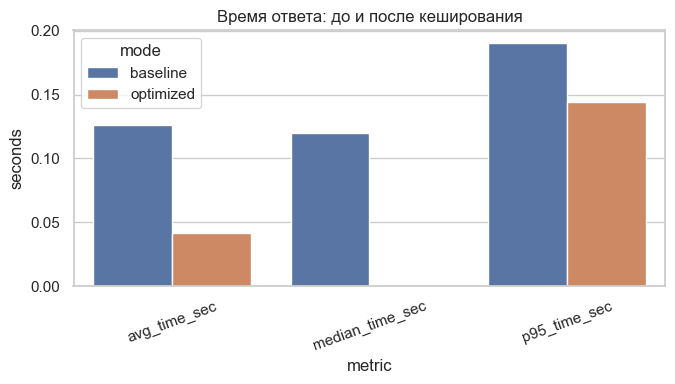

In [141]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_df = perf_df.melt(id_vars='mode', value_vars=['avg_time_sec', 'median_time_sec', 'p95_time_sec'], var_name='metric', value_name='seconds')
sns.barplot(data=plot_df, x='metric', y='seconds', hue='mode', ax=ax)
ax.set_title('Время ответа: до и после кеширования')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()

plt.show()
